In [59]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [60]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_val_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [61]:
full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
full_test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

CLASS_CAT = 3
CLASS_DOG = 5

def get_cat_dog_indices(dataset):
    return [i for i, (_, label) in enumerate(dataset) if label in [CLASS_CAT, CLASS_DOG]]

train_indices = get_cat_dog_indices(full_train_dataset)
test_indices = get_cat_dog_indices(full_test_dataset)

print(f"Sampel kucing dan anjing pada dataset latihan awal: {len(train_indices)} gambar")
print(f"Sub-total sampel kucing dan anjing pada dataset uji awal: {len(test_indices)} gambar")

Sampel kucing dan anjing pada dataset latihan awal: 10000 gambar
Sub-total sampel kucing dan anjing pada dataset uji awal: 2000 gambar


In [62]:
all_indices = train_indices + [idx + len(full_train_dataset) for idx in test_indices]

from torch.utils.data import ConcatDataset
combined_dataset = ConcatDataset([full_train_dataset, full_test_dataset])

train_idx, temp_idx = train_test_split(all_indices, test_size=0.30, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=42)

class BinaryCatDogDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, indices, transform=None):
        self.base_dataset = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, label = self.base_dataset[self.indices[idx]]
        binary_label = 0 if label == CLASS_CAT else 1
        if self.transform:
            img = self.transform(img)
        return img, binary_label

train_dataset = BinaryCatDogDataset(combined_dataset, train_idx, transform=transform_train)
val_dataset = BinaryCatDogDataset(combined_dataset, val_idx, transform=transform_val_test)
test_dataset = BinaryCatDogDataset(combined_dataset, test_idx, transform=transform_val_test)

print(f"Data pelatihan siap digunakan   : {len(train_dataset)} sampel")
print(f"Data validasi siap digunakan    : {len(val_dataset)} sampel")
print(f"Data pengujian siap digunakan   : {len(test_dataset)}  sampel")

Data pelatihan siap digunakan   : 8400 sampel
Data validasi siap digunakan    : 1800 sampel
Data pengujian siap digunakan   : 1800  sampel


In [63]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

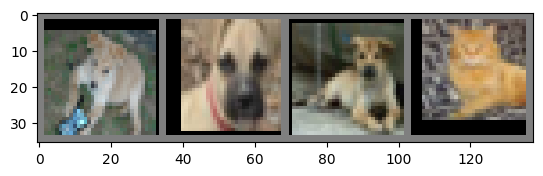

Daftar nilai target biner : [1, 1, 1, 0]
Daftar nama kelas target  : ['Dog', 'Dog', 'Dog', 'Cat']


In [80]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.savefig('cifar_sample.png', bbox_inches='tight', dpi=300)
    plt.show()

classes = ['Cat', 'Dog']
imshow(torchvision.utils.make_grid(images[:4]))
print('Daftar nilai target biner :', [int(labels[i]) for i in range(4)])
print('Daftar nama kelas target  :', [classes[labels[i]] for i in range(4)])

In [65]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.4)
        
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        
        x = x.view(-1, 128 * 4 * 4)
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_scratch = SimpleCNN().to(device)
print(f"Inisialisasi arsitektur CNN berhasil. Model dimuat pada: {device}")

Inisialisasi arsitektur CNN berhasil. Model dimuat pada: cuda


In [67]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_scratch.parameters(), lr=0.001, weight_decay=1e-4)

In [68]:
import time

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=15):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'train_time': 0}
    
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = 100. * correct / total
        
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
                
        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = 100. * val_correct / val_total
        
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        
        print(f"Epoch {epoch+1:02d}/{epochs:02d} -> "
              f"Loss Latihan: {epoch_train_loss:.4f} | Akurasi Latihan: {epoch_train_acc:.2f}% | "
              f"Loss Validasi: {epoch_val_loss:.4f} | Akurasi Validasi: {epoch_val_acc:.2f}%")
        
    end_time = time.time()
    history['train_time'] = end_time - start_time
    print(f"\nProses pelatihan selesai. Total waktu eksekusi: {history['train_time']:.2f} detik.")
    return history

In [69]:
print("Memulai proses pelatihan model CNN (From Scratch)...")
scratch_history = train_model(model_scratch, train_loader, val_loader, criterion, optimizer, epochs=15)

Memulai proses pelatihan model CNN (From Scratch)...
Epoch 01/15 -> Loss Latihan: 0.6936 | Akurasi Latihan: 57.83% | Loss Validasi: 0.6433 | Akurasi Validasi: 61.56%
Epoch 02/15 -> Loss Latihan: 0.6251 | Akurasi Latihan: 64.42% | Loss Validasi: 0.5613 | Akurasi Validasi: 70.56%
Epoch 03/15 -> Loss Latihan: 0.5720 | Akurasi Latihan: 69.30% | Loss Validasi: 0.5242 | Akurasi Validasi: 72.83%
Epoch 04/15 -> Loss Latihan: 0.5399 | Akurasi Latihan: 72.23% | Loss Validasi: 0.7977 | Akurasi Validasi: 64.78%
Epoch 05/15 -> Loss Latihan: 0.5210 | Akurasi Latihan: 73.58% | Loss Validasi: 0.5408 | Akurasi Validasi: 72.78%
Epoch 06/15 -> Loss Latihan: 0.4914 | Akurasi Latihan: 75.77% | Loss Validasi: 0.4582 | Akurasi Validasi: 77.78%
Epoch 07/15 -> Loss Latihan: 0.4831 | Akurasi Latihan: 76.86% | Loss Validasi: 0.5525 | Akurasi Validasi: 71.61%
Epoch 08/15 -> Loss Latihan: 0.4795 | Akurasi Latihan: 76.81% | Loss Validasi: 0.4448 | Akurasi Validasi: 78.06%
Epoch 09/15 -> Loss Latihan: 0.4681 | Akura

In [71]:
import os
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import kagglehub

downloaded_path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")
base_path_tl = os.path.join(downloaded_path, "PetImages")

if not os.path.exists(base_path_tl):
    base_path_tl = downloaded_path

tl_transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

tl_transform_val_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset_tl = ImageFolder(root=base_path_tl)
total_tl_images = len(full_dataset_tl)

sampled_indices_tl, _ = train_test_split(
    list(range(total_tl_images)), 
    train_size=min(4000, total_tl_images), 
    stratify=full_dataset_tl.targets, 
    random_state=42
)

tl_train_idx, tl_temp_idx = train_test_split(sampled_indices_tl, test_size=0.30, random_state=42)
tl_val_idx, tl_test_idx = train_test_split(tl_temp_idx, test_size=0.50, random_state=42)

class TLDatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, base_dataset, indices, transform=None):
        self.base_dataset = base_dataset
        self.indices = indices
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        img, label = self.base_dataset[self.indices[idx]]
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset_tl = TLDatasetWrapper(base_dataset=full_dataset_tl, indices=tl_train_idx, transform=tl_transform_train)
val_dataset_tl = TLDatasetWrapper(base_dataset=full_dataset_tl, indices=tl_val_idx, transform=tl_transform_val_test)
test_dataset_tl = TLDatasetWrapper(base_dataset=full_dataset_tl, indices=tl_test_idx, transform=tl_transform_val_test)

BATCH_SIZE_TL = 64
tl_train_loader = DataLoader(train_dataset_tl, batch_size=BATCH_SIZE_TL, shuffle=True, num_workers=2)
tl_val_loader = DataLoader(val_dataset_tl, batch_size=BATCH_SIZE_TL, shuffle=False, num_workers=2)
tl_test_loader = DataLoader(test_dataset_tl, batch_size=BATCH_SIZE_TL, shuffle=False, num_workers=2)

print("Data transfer learning berhasil dimuat:")
print(f"- Latihan  : {len(train_dataset_tl)} gambar")
print(f"- Validasi : {len(val_dataset_tl)} gambar")
print(f"- Pengujian: {len(test_dataset_tl)} gambar")

Data transfer learning berhasil dimuat:
- Latihan  : 2800 gambar
- Validasi : 600 gambar
- Pengujian: 600 gambar


In [72]:
import torch.nn as nn
import torchvision.models as models

weights_v2 = models.MobileNet_V2_Weights.DEFAULT
model_transfer = models.mobilenet_v2(weights=weights_v2)

for param in model_transfer.parameters():
    param.requires_grad = False

num_features_tl = model_transfer.classifier[1].in_features
model_transfer.classifier[1] = nn.Linear(num_features_tl, 2)

model_transfer = model_transfer.to(device)
print(f"Model MobileNetV2 berhasil dikonfigurasi pada: {device}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 110MB/s] 

Model MobileNetV2 berhasil dikonfigurasi pada: cuda


In [73]:
import torch.optim as optim

optimizer_tl = optim.Adam(model_transfer.classifier.parameters(), lr=0.001)

print("Memulai proses pelatihan model Transfer Learning...")
tl_history = train_model(model_transfer, tl_train_loader, tl_val_loader, criterion, optimizer_tl, epochs=5)

Memulai proses pelatihan model Transfer Learning...


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 01/05 -> Loss Latihan: 0.3349 | Akurasi Latihan: 88.68% | Loss Validasi: 0.1828 | Akurasi Validasi: 94.67%


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 02/05 -> Loss Latihan: 0.1577 | Akurasi Latihan: 95.79% | Loss Validasi: 0.1429 | Akurasi Validasi: 95.00%


...

Epoch 03/05 -> Loss Latihan: 0.1273 | Akurasi Latihan: 95.79% | Loss Validasi: 0.1251 | Akurasi Validasi: 95.67%


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 04/05 -> Loss Latihan: 0.1152 | Akurasi Latihan: 96.36% | Loss Validasi: 0.1194 | Akurasi Validasi: 95.50%


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 05/05 -> Loss Latihan: 0.1043 | Akurasi Latihan: 96.82% | Loss Validasi: 0.1065 | Akurasi Validasi: 96.17%

Proses pelatihan selesai. Total waktu eksekusi: 60.85 detik.


In [74]:
def evaluate_test_set(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total

acc_scratch = evaluate_test_set(model_scratch, test_loader)
acc_transfer = evaluate_test_set(model_transfer, tl_test_loader)

print(f"Akurasi Pengujian CNN from Scratch : {acc_scratch:.2f}%")
print(f"Akurasi Pengujian Transfer Learning : {acc_transfer:.2f}%")

Akurasi Pengujian CNN from Scratch : 79.83%
Akurasi Pengujian Transfer Learning : 98.67%


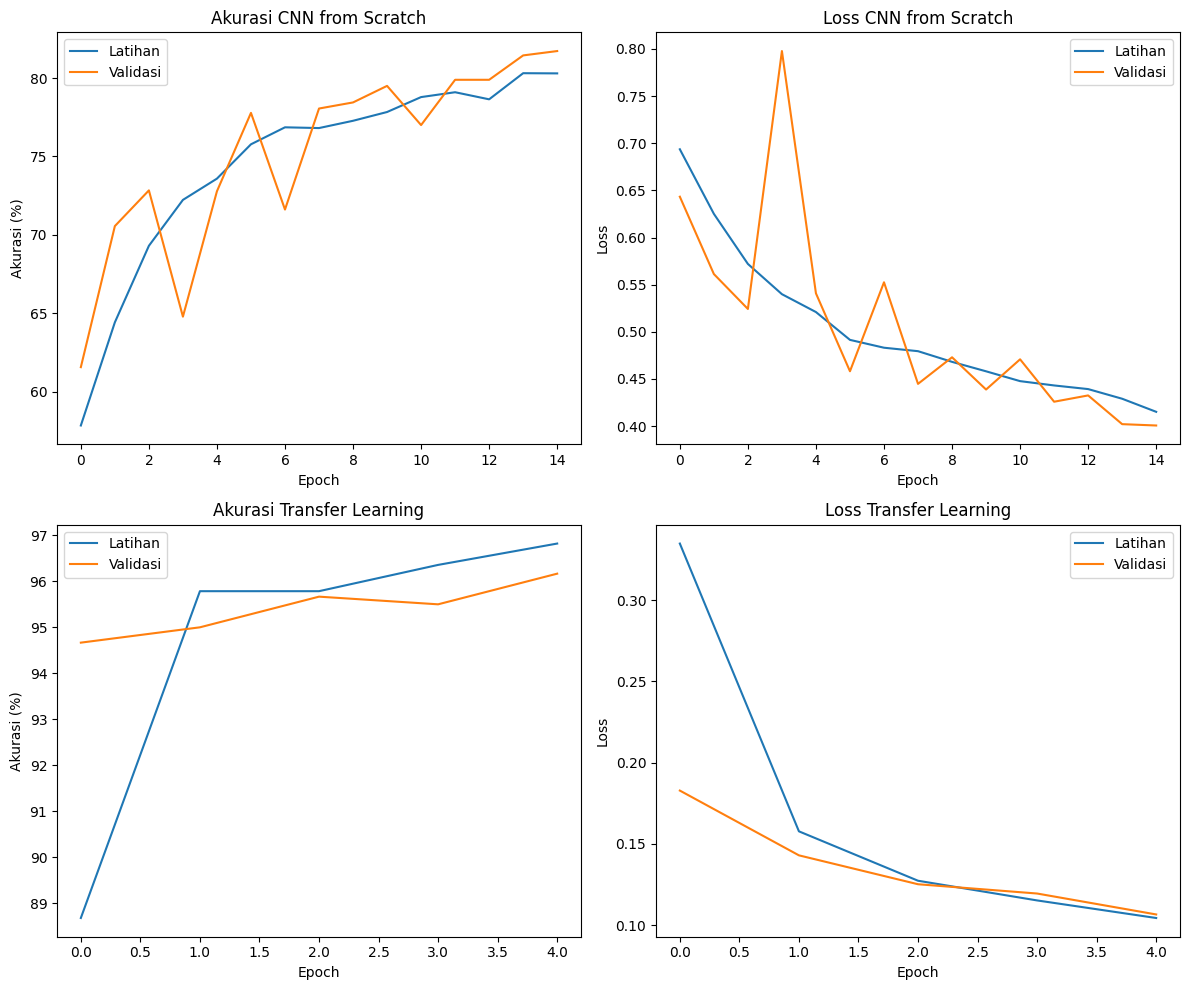

In [81]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].plot(scratch_history['train_acc'], label='Latihan')
axs[0, 0].plot(scratch_history['val_acc'], label='Validasi')
axs[0, 0].set_title('Akurasi CNN from Scratch')
axs[0, 0].set_xlabel('Epoch')
axs[0, 0].set_ylabel('Akurasi (%)')
axs[0, 0].legend()

axs[0, 1].plot(scratch_history['train_loss'], label='Latihan')
axs[0, 1].plot(scratch_history['val_loss'], label='Validasi')
axs[0, 1].set_title('Loss CNN from Scratch')
axs[0, 1].set_xlabel('Epoch')
axs[0, 1].set_ylabel('Loss')
axs[0, 1].legend()

axs[1, 0].plot(tl_history['train_acc'], label='Latihan')
axs[1, 0].plot(tl_history['val_acc'], label='Validasi')
axs[1, 0].set_title('Akurasi Transfer Learning')
axs[1, 0].set_xlabel('Epoch')
axs[1, 0].set_ylabel('Akurasi (%)')
axs[1, 0].legend()

axs[1, 1].plot(tl_history['train_loss'], label='Latihan')
axs[1, 1].plot(tl_history['val_loss'], label='Validasi')
axs[1, 1].set_title('Loss Transfer Learning')
axs[1, 1].set_xlabel('Epoch')
axs[1, 1].set_ylabel('Loss')
axs[1, 1].legend()

plt.tight_layout()
plt.savefig('metrics_plot.png', bbox_inches='tight', dpi=300)
plt.show()

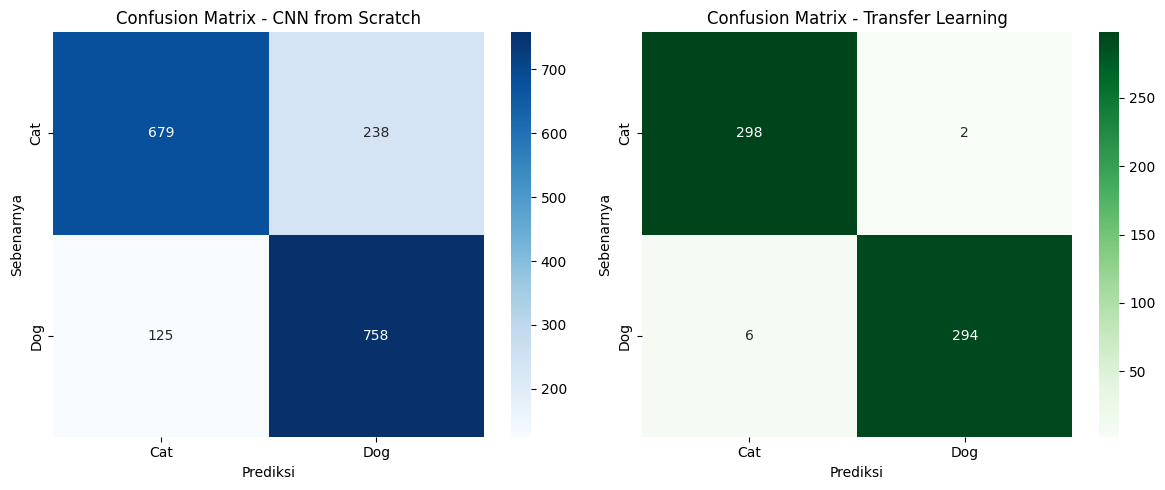

In [82]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def get_all_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

preds_scratch, labels_scratch = get_all_predictions(model_scratch, test_loader)
preds_tl, labels_tl = get_all_predictions(model_transfer, tl_test_loader)

cm_scratch = confusion_matrix(labels_scratch, preds_scratch)
cm_tl = confusion_matrix(labels_tl, preds_tl)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_scratch, annot=True, fmt='d', cmap='Blues', ax=axs[0], xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
axs[0].set_title('Confusion Matrix - CNN from Scratch')
axs[0].set_xlabel('Prediksi')
axs[0].set_ylabel('Sebenarnya')

sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens', ax=axs[1], xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
axs[1].set_title('Confusion Matrix - Transfer Learning')
axs[1].set_xlabel('Prediksi')
axs[1].set_ylabel('Sebenarnya')

plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()

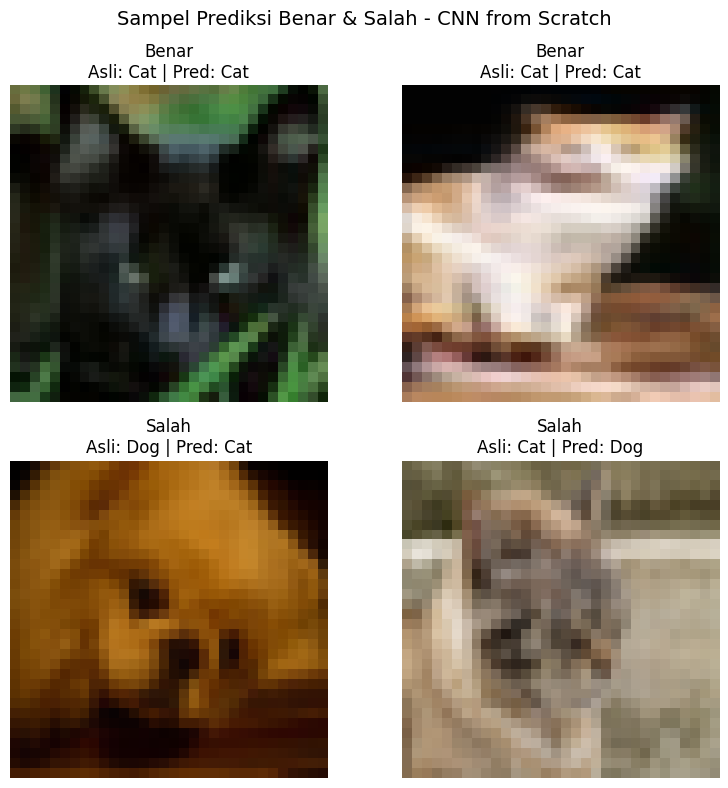

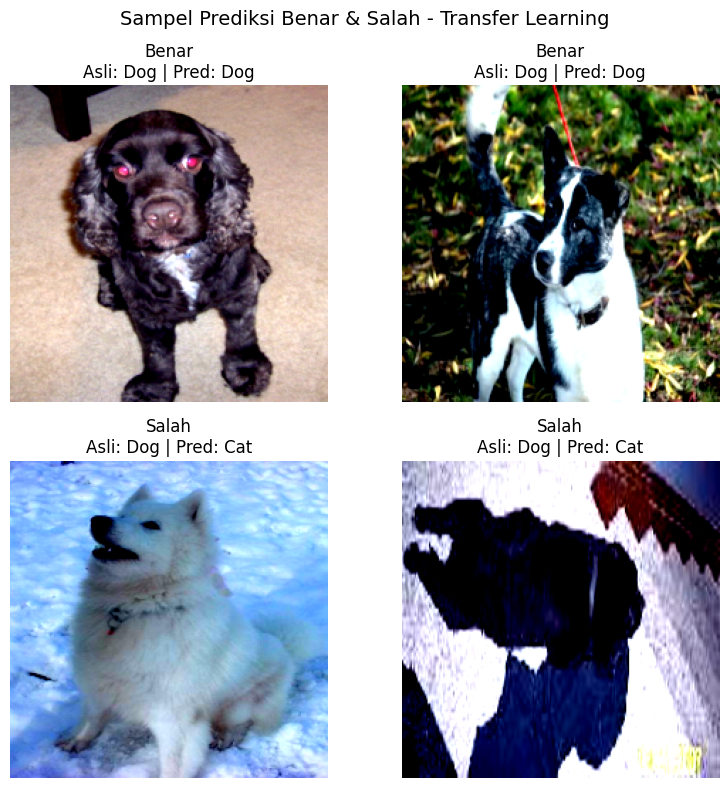

In [85]:
def plot_predictions(model, loader, title_prefix, filename):
    model.eval()
    correct_imgs, incorrect_imgs = [], []
    correct_labels, incorrect_labels = [], []
    correct_preds, incorrect_preds = [], []
    
    with torch.no_grad():
        for images, labels in loader:
            images_dev = images.to(device)
            outputs = model(images_dev)
            _, predicted = outputs.max(1)
            predicted = predicted.cpu()
            
            for i in range(len(labels)):
                img_unnorm = images[i] / 2 + 0.5
                img_np = np.transpose(img_unnorm.numpy(), (1, 2, 0))
                img_np = np.clip(img_np, 0, 1)
                
                if predicted[i] == labels[i]:
                    if len(correct_imgs) < 2:
                        correct_imgs.append(img_np)
                        correct_labels.append(int(labels[i]))
                        correct_preds.append(int(predicted[i]))
                else:
                    if len(incorrect_imgs) < 2:
                        incorrect_imgs.append(img_np)
                        incorrect_labels.append(int(labels[i]))
                        incorrect_preds.append(int(predicted[i]))
                        
            if len(correct_imgs) >= 2 and len(incorrect_imgs) >= 2:
                break
                
    fig, axs = plt.subplots(2, 2, figsize=(8, 8))
    fig.suptitle(f"Sampel Prediksi Benar & Salah - {title_prefix}", fontsize=14)
    
    classes = ['Cat', 'Dog']
    
    for i in range(2):
        axs[0, i].imshow(correct_imgs[i])
        axs[0, i].set_title(f"Benar\nAsli: {classes[correct_labels[i]]} | Pred: {classes[correct_preds[i]]}")
        axs[0, i].axis('off')
        
        axs[1, i].imshow(incorrect_imgs[i])
        axs[1, i].set_title(f"Salah\nAsli: {classes[incorrect_labels[i]]} | Pred: {classes[incorrect_preds[i]]}")
        axs[1, i].axis('off')
        
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.show()

plot_predictions(model_scratch, test_loader, "CNN from Scratch", "scratch_pred.png")
plot_predictions(model_transfer, tl_test_loader, "Transfer Learning", "tl_pred.png")

In [78]:
params_scratch = sum(p.numel() for p in model_scratch.parameters())
params_tl = sum(p.numel() for p in model_transfer.parameters())

print(f"Total Parameter CNN from Scratch : {params_scratch:,}")
print(f"Total Parameter Transfer Learning : {params_tl:,}")

Total Parameter CNN from Scratch : 618,754
Total Parameter Transfer Learning : 2,226,434
